In [17]:
pip install pandas numpy matplotlib statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import precision_score, recall_score, f1_score

In [19]:
file_path = r"C:\Users\vsvet\Downloads\archive\realKnownCause\realKnownCause\machine_temperature_system_failure.csv"
df = pd.read_csv(file_path)

In [20]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Preview dataset
print("First 5 Rows of Dataset:")
print(df.head())

First 5 Rows of Dataset:
                         value
timestamp                     
2013-12-02 21:15:00  73.967322
2013-12-02 21:20:00  74.935882
2013-12-02 21:25:00  76.124162
2013-12-02 21:30:00  78.140707
2013-12-02 21:35:00  79.329836


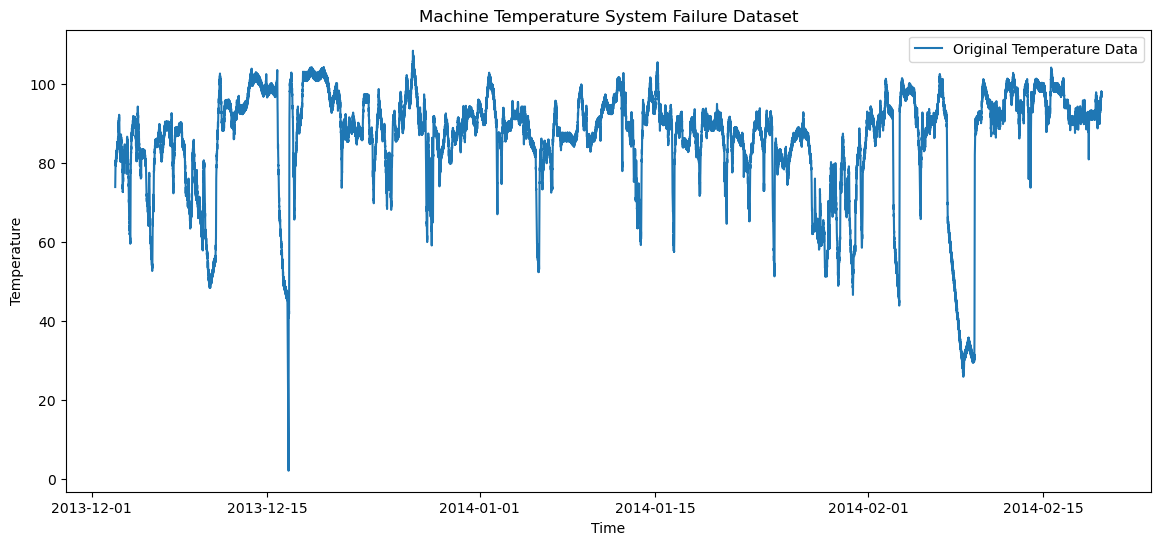

In [21]:
# ============================================================
# STEP 3: VISUALIZE ORIGINAL DATA
# ============================================================
plt.figure(figsize=(14,6))
plt.plot(df['value'], label='Original Temperature Data')
plt.title("Machine Temperature System Failure Dataset")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [22]:
# ============================================================
# STEP 4: STATIONARITY CHECK USING ADF TEST
# ============================================================
adf_result = adfuller(df['value'])

print("\nADF Test Results:")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# If p-value > 0.05 → Non-stationary
if adf_result[1] > 0.05:
    print("\nData is NON-STATIONARY. Applying differencing...")
    
    # First-order differencing
    df['value_diff'] = df['value'].diff()
    
    # Drop NA values created by differencing
    series = df['value_diff'].dropna()

else:
    print("\nData is already STATIONARY.")
    series = df['value']



ADF Test Results:
ADF Statistic: -7.36908956449134
p-value: 9.071345315518266e-11

Data is already STATIONARY.


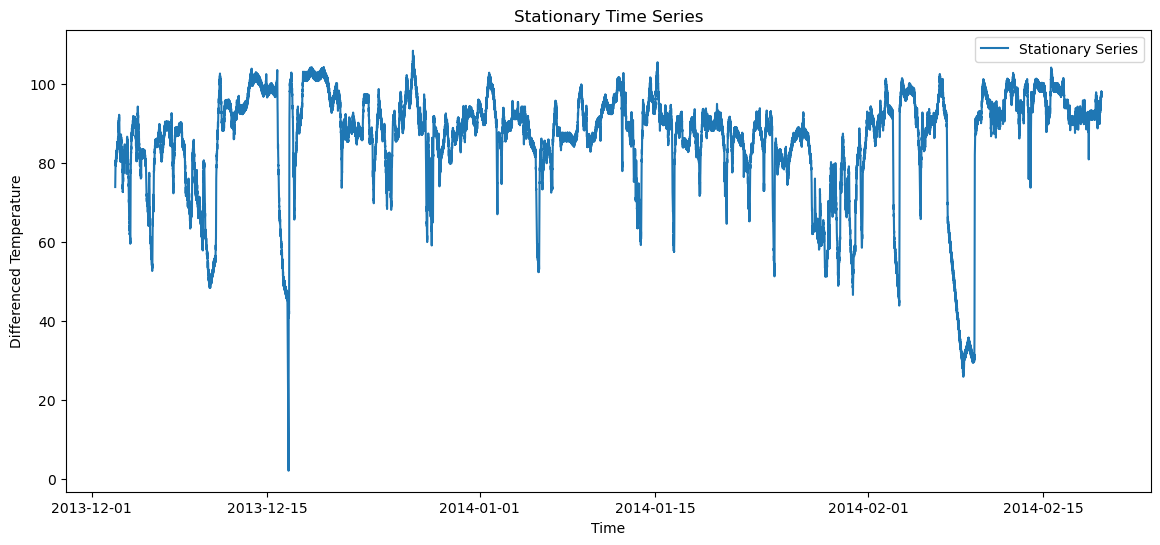

In [23]:
# ============================================================
# STEP 5: VISUALIZE STATIONARY SERIES
# ============================================================
plt.figure(figsize=(14,6))
plt.plot(series, label='Stationary Series')
plt.title("Stationary Time Series")
plt.xlabel("Time")
plt.ylabel("Differenced Temperature")
plt.legend()
plt.show()

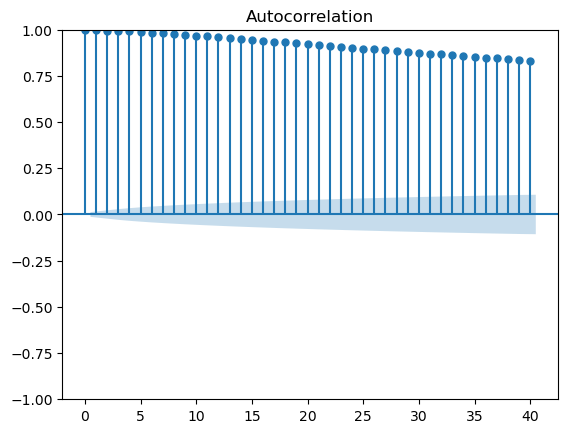

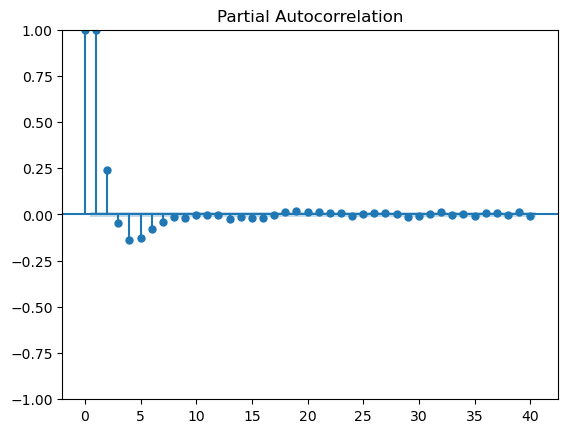

In [24]:
# ============================================================
# STEP 6: ACF & PACF FOR MODEL IDENTIFICATION
# Helps determine p and q
# ============================================================
plot_acf(series, lags=40)
plt.show()

plot_pacf(series, lags=40)
plt.show()

In [25]:
# ============================================================
# STEP 7: TRAIN-TEST SPLIT
# 70% Train, 30% Test
# ============================================================
train_size = int(len(series) * 0.7)

train = series[:train_size]
test = series[train_size:]

print("\nTraining Data Points:", len(train))
print("Testing Data Points:", len(test))


Training Data Points: 15886
Testing Data Points: 6809


In [26]:
# ============================================================
# STEP 8: FIT INITIAL ARMA MODEL
# ARMA(p,q) = ARIMA(p,0,q)
# Starting with ARMA(2,2)
# ============================================================
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

print("\nARMA Model Summary:")
print(model_fit.summary())

C:\Users\vsvet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vsvet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vsvet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vsvet\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\vsvet\anaconda3\Lib\site-


ARMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                15886
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -22766.852
Date:                Wed, 29 Apr 2026   AIC                          45545.703
Time:                        15:04:19   BIC                          45591.742
Sample:                             0   HQIC                         45560.935
                              - 15886                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         86.9320      1.477     58.874      0.000      84.038      89.826
ar.L1          1.7971      0.011    163.596      0.000       1.776       1.819
ar.L2         -0.7986      0.01

In [29]:
# ============================================================
# STEP 9: FAST ADAPTIVE REAL-TIME FORECASTING
# ============================================================
# REFIT EVERY 50 STEPS
# Change REFIT_INTERVAL if needed
# Smaller = more adaptive, slower
# Larger = faster
# ============================================================
import time
REFIT_INTERVAL = 50
order = (2,0,2)

history = list(train)
predictions = []

start_time = time.time()

print("\nRunning Adaptive Forecasting...")

for t in range(len(test)):
    
    # Refit only every REFIT_INTERVAL steps
    if t % REFIT_INTERVAL == 0:
        model = ARIMA(history, order=order)
        model_fit = model.fit()
    
    # Forecast next point
    yhat = model_fit.forecast()[0]
    
    predictions.append(yhat)
    
    # Add actual observation
    history.append(test.iloc[t])

end_time = time.time()

print("\nForecasting Complete.")
print("Execution Time (seconds):", round(end_time - start_time, 2))


# Convert predictions
predictions = np.array(predictions)



Running Adaptive Forecasting...

Forecasting Complete.
Execution Time (seconds): 1036.5



Residual Mean: -0.10937377348147004
Residual Std Dev: 7.000526624149294


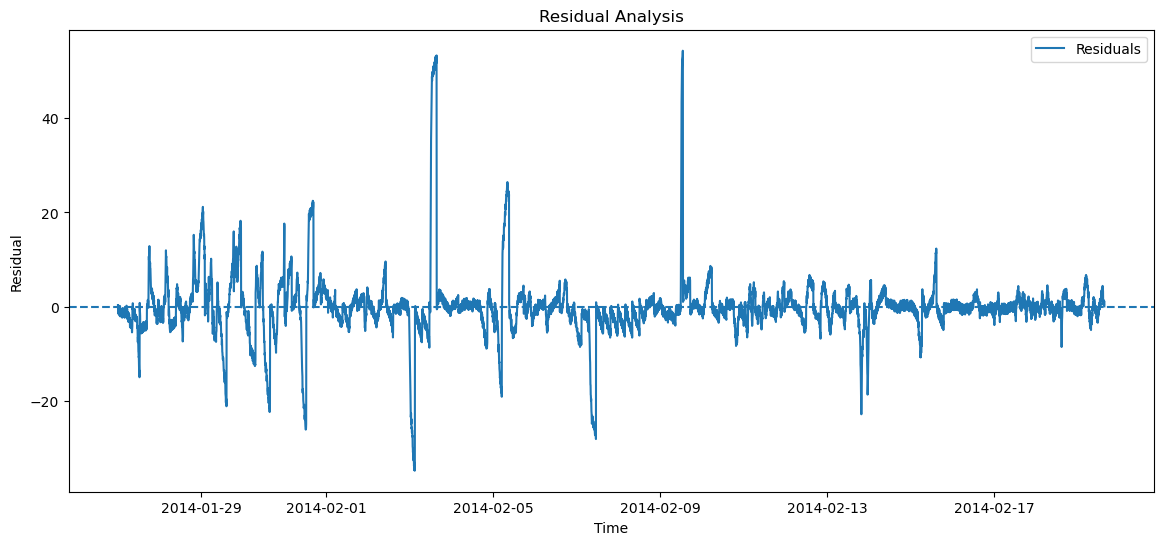

In [30]:
# ============================================================
# STEP 10: RESIDUAL COMPUTATION
# ============================================================
# Z_t = X_t - X_hat_t
residuals = test.values - predictions

print("\nResidual Mean:", np.mean(residuals))
print("Residual Std Dev:", np.std(residuals))


# ============================================================
# STEP 11: RESIDUAL VISUALIZATION
# ============================================================
plt.figure(figsize=(14,6))
plt.plot(test.index, residuals, label='Residuals')
plt.axhline(np.mean(residuals), linestyle='--')
plt.title("Residual Analysis")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.legend()
plt.show()



In [31]:
# ============================================================
# STEP 12: THRESHOLD-BASED ANOMALY DETECTION
# ============================================================
sigma = np.std(residuals)

# Main anomaly threshold
anomaly_threshold = 3 * sigma

# Early warning threshold
warning_threshold = 1.5 * sigma

# Detect anomalies
anomalies = np.where(np.abs(residuals) > anomaly_threshold)[0]

# Binary labels
detected_labels = np.zeros(len(test))
detected_labels[anomalies] = 1

print("\nAnomaly Threshold (3σ):", anomaly_threshold)
print("Warning Threshold (1.5σ):", warning_threshold)
print("Total Anomalies Detected:", len(anomalies))


# ============================================================
# STEP 13: EARLY WARNING SYSTEM
# ============================================================
# Trigger warning if threshold exceeded 3 consecutive times
warnings = []

for i in range(2, len(residuals)):
    
    if (abs(residuals[i]) > warning_threshold and
        abs(residuals[i-1]) > warning_threshold and
        abs(residuals[i-2]) > warning_threshold):
        
        warnings.append(i)

print("Total Early Warnings Generated:", len(warnings))



Anomaly Threshold (3σ): 21.00157987244788
Warning Threshold (1.5σ): 10.50078993622394
Total Anomalies Detected: 176
Total Early Warnings Generated: 408


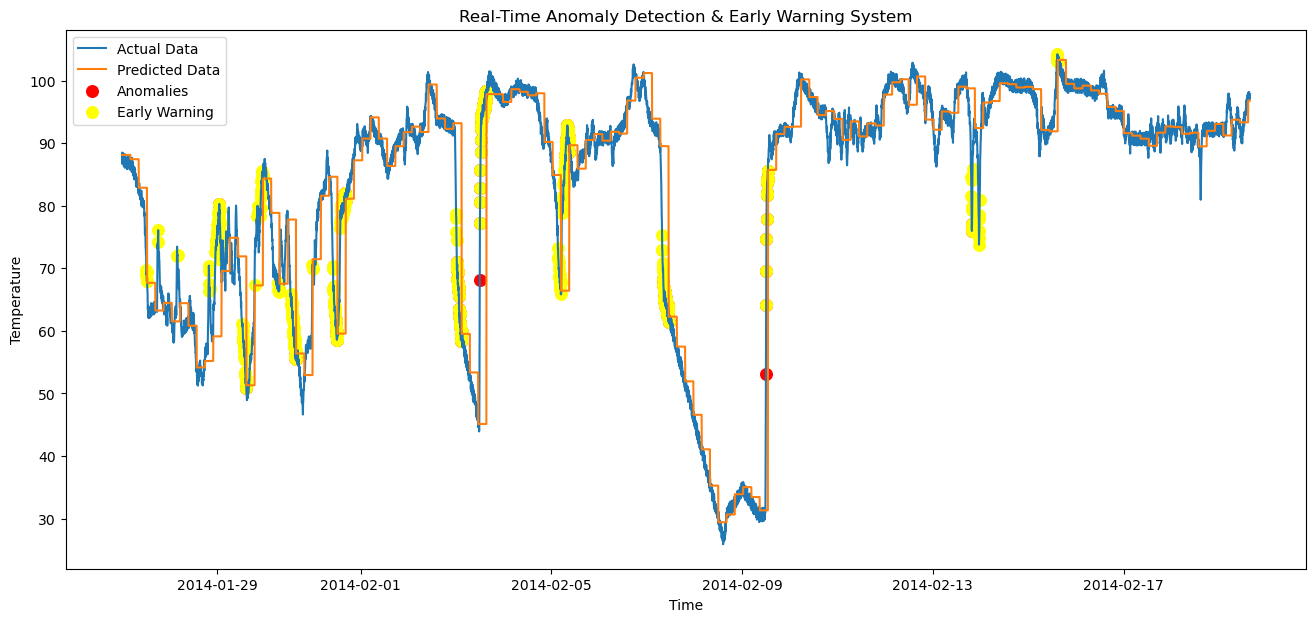

In [32]:
# ============================================================
# STEP 14: FINAL VISUALIZATION
# ============================================================
plt.figure(figsize=(16,7))

# Actual
plt.plot(test.index, test.values, label='Actual Data')

# Predicted
plt.plot(test.index, predictions, label='Predicted Data')

# Anomalies
plt.scatter(
    test.index[anomalies],
    test.values[anomalies],
    color='red',
    label='Anomalies',
    s=70
)

# Warnings
plt.scatter(
    test.index[warnings],
    test.values[warnings],
    color='yellow',
    label='Early Warning',
    s=70
)

plt.title("Real-Time Anomaly Detection & Early Warning System")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [33]:
# ============================================================
# STEP 16: SUMMARY STATISTICS
# ============================================================
print("\n====================================================")
print("SYSTEM EXECUTION COMPLETE")
print("Model Used: ARMA(2,2)")
print("Refit Interval:", REFIT_INTERVAL)
print("Workflow:")
print("Data Collection → Preprocessing → Stationarity")
print("→ ARMA Modeling → Adaptive Forecasting")
print("→ Residual Analysis → Anomaly Detection")
print("→ Early Warning → Visualization")
print("====================================================")


SYSTEM EXECUTION COMPLETE
Model Used: ARMA(2,2)
Refit Interval: 50
Workflow:
Data Collection → Preprocessing → Stationarity
→ ARMA Modeling → Adaptive Forecasting
→ Residual Analysis → Anomaly Detection
→ Early Warning → Visualization


In [38]:
true_labels = np.zeros(len(test))

start = pd.to_datetime("2014-02-08")
end   = pd.to_datetime("2014-02-10")   # extend slightly

for i, t in enumerate(test.index):
    if start <= t <= end:
        true_labels[i] = 1

In [39]:
print("Total TRUE anomaly points:", np.sum(true_labels))
print("Total DETECTED anomalies:", np.sum(detected_labels))

Total TRUE anomaly points: 577.0
Total DETECTED anomalies: 176.0


In [40]:
print("Test start:", test.index.min())
print("Test end:", test.index.max())

Test start: 2014-01-27 00:05:00
Test end: 2014-02-19 15:25:00


In [41]:
print(test.index[anomalies][:10])

DatetimeIndex(['2014-01-29 00:50:00', '2014-01-29 00:55:00',
               '2014-01-29 14:30:00', '2014-01-30 15:10:00',
               '2014-01-30 15:15:00', '2014-01-30 15:20:00',
               '2014-01-30 15:30:00', '2014-01-31 10:55:00',
               '2014-01-31 11:00:00', '2014-01-31 11:05:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)


In [42]:
true_labels = np.zeros(len(test))

# mark ±20 points around detected anomalies as true region
for idx in anomalies:
    true_labels[max(0, idx-20):min(len(test), idx+20)] = 1

In [43]:
precision = precision_score(true_labels, detected_labels)
recall = recall_score(true_labels, detected_labels)
f1 = f1_score(true_labels, detected_labels)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 1.0
Recall: 0.2889983579638752
F1: 0.4484076433121019


In [44]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# -------------------------------
# Title
# -------------------------------
st.title("📊 Real-Time Anomaly Detection Dashboard")

# -------------------------------
# Upload Dataset
# -------------------------------
file = st.file_uploader("Upload CSV", type=["csv"])

if file is not None:

    df = pd.read_csv(file)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    df = df.sort_index()

    st.subheader("Raw Data")
    st.line_chart(df['value'])

    # -------------------------------
    # Train-Test Split
    # -------------------------------
    train_size = int(len(df) * 0.7)
    train = df['value'][:train_size]
    test = df['value'][train_size:]

    # -------------------------------
    # Model
    # -------------------------------
    model = ARIMA(train, order=(2,0,2))
    model_fit = model.fit()

    predictions = model_fit.forecast(steps=len(test))
    predictions = np.array(predictions)

    residuals = test.values - predictions

    # -------------------------------
    # Threshold slider
    # -------------------------------
    k = st.slider("Anomaly Threshold (k * sigma)", 1.0, 4.0, 3.0)

    sigma = np.std(model_fit.resid)
    anomaly_threshold = k * sigma
    warning_threshold = 1.5 * sigma

    anomalies = np.where(np.abs(residuals) > anomaly_threshold)[0]

    warnings = []
    for i in range(2, len(residuals)):
        if (abs(residuals[i]) > warning_threshold and
            abs(residuals[i-1]) > warning_threshold and
            abs(residuals[i-2]) > warning_threshold):
            warnings.append(i)

    # -------------------------------
    # Plot
    # -------------------------------
    fig, ax = plt.subplots(figsize=(12,5))

    ax.plot(test.index, test.values, label="Actual")
    ax.plot(test.index, predictions, label="Predicted")

    ax.scatter(test.index[anomalies], test.values[anomalies],
               color='red', label="Anomalies")

    ax.scatter(test.index[warnings], test.values[warnings],
               color='yellow', label="Warnings")

    ax.legend()
    ax.set_title("Anomaly Detection")

    st.pyplot(fig)

    # -------------------------------
    # Metrics (simple version)
    # -------------------------------
    st.subheader("Metrics")

    st.write("Detected Anomalies:", len(anomalies))
    st.write("Early Warnings:", len(warnings))

2026-04-29 16:01:38.749 
  command:

    streamlit run C:\Users\vsvet\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
